# Trial 0 Sentence-Onset Gamma Features (STG-only)

This notebook extracts balanced control/onset windows around sentence onsets for `sub_2` trial 0, computes gamma-band and total power features using STG electrodes only, and trains linear classifiers.

In [1]:
from pathlib import Path
import warnings

import h5py
import numpy as np
import pandas as pd
from scipy import signal

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
# sns.set_theme(style='whitegrid')

In [2]:
plt.rcParams['image.cmap'] = 'magma'
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['lines.linewidth'] = 2
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.minor.size'] = 3
plt.rcParams['xtick.major.width'] = 2
plt.rcParams['ytick.major.width'] = 2
plt.rcParams['xtick.minor.width'] = 1
plt.rcParams['ytick.minor.width'] = 1
plt.rcParams['legend.frameon'] = False

In [3]:
# Paths and constants
import sys

# Find repo root so notebook can import shared path config from configs/config.py.
_repo_root = None
for _cand in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    if (_cand / 'configs' / 'config.py').exists():
        _repo_root = _cand
        break
if _repo_root is None:
    raise RuntimeError('Could not find repo root containing configs/config.py')
if str(_repo_root) not in sys.path:
    sys.path.insert(0, str(_repo_root))

from configs.config import get_config

PATH_PROFILE = 'local'  # change to 'server' when running on server
CFG = get_config(PATH_PROFILE)
ROOT = CFG.brain_tree_root
H5_PATH = ROOT / 'sub_2_trial000.h5'
META_PATH = ROOT / 'subject_metadata' / 'sub_2_trial000_metadata.json'
TIMINGS_PATH = ROOT / 'subject_timings' / 'sub_2_trial000_timings.csv'
LOCALIZATION_PATH = ROOT / 'localization' / 'elec_coords_full.csv'
ELECTRODE_LABELS_PATH = ROOT / 'electrode_labels' / 'sub_2' / 'electrode_labels.json'
CORRUPTED_ELEC_PATH = ROOT / 'corrupted_elec.json'

SUBJECT = 'sub_2'
TRIAL = 0
TEST_SIZE = 0.2
CONTROL_SEC = 0.5
ONSET_START_SEC = 0.2
ONSET_END_SEC = 0.7
GAMMA_BAND = (50.0, 200.0)
NOTCH_FREQS = (60.0, 120.0, 180.0)
NOTCH_Q = 30.0
TEMPORAL_KEYWORD = 'temporal'
TSTAT_THRESHOLD = 2.0
RNG = 7


In [4]:
# Visualize H5 structure and attributes

def print_h5_tree(group, prefix=''):
    keys = list(group.keys())
    for i, key in enumerate(keys):
        obj = group[key]
        connector = '└── ' if i == len(keys) - 1 else '├── '
        if isinstance(obj, h5py.Group):
            print(f"{prefix}{connector}{key}/")
            next_prefix = prefix + ('    ' if i == len(keys) - 1 else '│   ')
            print_h5_tree(obj, next_prefix)
        else:
            print(f"{prefix}{connector}{key} {obj.shape} {obj.dtype}")

with h5py.File(H5_PATH, 'r') as h5f:
    print('H5 root keys:', list(h5f.keys()))
    print('Root attrs:', dict(h5f.attrs))
    if 'data' in h5f:
        print('data attrs:', dict(h5f['data'].attrs))
    print('\nH5 tree:')
    print_h5_tree(h5f)


H5 root keys: ['data']
Root attrs: {}
data attrs: {'orig_data_hash': 'f84ace031de03eb6b4f5b03ecf46f008'}

H5 tree:
└── data/
    ├── electrode_0 (19181016,) float64
    ├── electrode_1 (19181016,) float64
    ├── electrode_10 (19181016,) float64
    ├── electrode_100 (19181016,) float64
    ├── electrode_101 (19181016,) float64
    ├── electrode_102 (19181016,) float64
    ├── electrode_103 (19181016,) float64
    ├── electrode_104 (19181016,) float64
    ├── electrode_105 (19181016,) float64
    ├── electrode_106 (19181016,) float64
    ├── electrode_107 (19181016,) float64
    ├── electrode_108 (19181016,) float64
    ├── electrode_109 (19181016,) float64
    ├── electrode_11 (19181016,) float64
    ├── electrode_110 (19181016,) float64
    ├── electrode_111 (19181016,) float64
    ├── electrode_112 (19181016,) float64
    ├── electrode_113 (19181016,) float64
    ├── electrode_114 (19181016,) float64
    ├── electrode_115 (19181016,) float64
    ├── electrode_116 (19181016,) float64

In [5]:
# Metadata and transcript mapping
meta = pd.read_json(META_PATH, typ='series')
movie_name = meta['filename']
TRANSCRIPT_PATH = ROOT / 'transcripts' / movie_name / 'features.csv'

print(f'Movie for trial {TRIAL}: {movie_name}')
print(f'Transcript: {TRANSCRIPT_PATH}')


Movie for trial 0: venom
Transcript: /Users/wojemann/local_data/gamma-recon/brain_tree/transcripts/venom/features.csv


In [6]:
# Load transcript and sentence onsets
transcript = pd.read_csv(TRANSCRIPT_PATH)
transcript['start'] = pd.to_numeric(transcript['start'], errors='coerce')
transcript['end'] = pd.to_numeric(transcript['end'], errors='coerce')
transcript['is_onset'] = pd.to_numeric(transcript['is_onset'], errors='coerce').fillna(0)
transcript['sentence_idx'] = pd.to_numeric(transcript['sentence_idx'], errors='coerce')

onsets = (
    transcript[transcript['is_onset'] == 1.0]
    .sort_values(['sentence_idx', 'start'])
    .drop_duplicates(subset=['sentence_idx'], keep='first')
    .reset_index(drop=True)
)

sentence_bounds = (
    transcript.groupby('sentence_idx', as_index=False)
    .agg(sentence_start=('start', 'min'), sentence_end=('end', 'max'))
    .sort_values('sentence_idx')
    .reset_index(drop=True)
)
sentence_bounds['prev_sentence_end'] = sentence_bounds['sentence_end'].shift(1)

onsets = onsets.merge(
    sentence_bounds[['sentence_idx', 'sentence_start', 'prev_sentence_end']],
    on='sentence_idx',
    how='left',
)
onsets = onsets.dropna(subset=['start', 'sentence_idx']).reset_index(drop=True)

print(f'Total sentence onsets available: {len(onsets)}')
print('Window targets: control [-500, 0] ms, onset [200, 700] ms relative to onset')


Total sentence onsets available: 1367
Window targets: control [-500, 0] ms, onset [200, 700] ms relative to onset


In [7]:
# Trigger alignment and sampling-rate check
timings = pd.read_csv(TIMINGS_PATH)
triggers = timings[timings['type'] == 'trigger'].copy()
triggers['movie_time'] = pd.to_numeric(triggers['movie_time'], errors='coerce')
triggers['start_time'] = pd.to_numeric(triggers['start_time'], errors='coerce')
triggers['index'] = pd.to_numeric(triggers['index'], errors='coerce')
triggers = triggers.dropna(subset=['movie_time', 'start_time', 'index']).sort_values('movie_time')

assert triggers['movie_time'].is_monotonic_increasing, 'movie_time is not monotonic'
assert triggers['index'].is_monotonic_increasing, 'sample index is not monotonic'

movie_time = triggers['movie_time'].to_numpy()
record_time = triggers['start_time'].to_numpy()
sample_index = triggers['index'].to_numpy()

fs_from_record = (sample_index[-1] - sample_index[0]) / (record_time[-1] - record_time[0])
fs_from_movie = (sample_index[-1] - sample_index[0]) / (movie_time[-1] - movie_time[0])

# Try to discover fs directly from H5 attributes first.
fs_h5 = None
with h5py.File(H5_PATH, 'r') as h5f:
    candidate_attrs = {}
    for k, v in dict(h5f.attrs).items():
        candidate_attrs[f'root:{k}'] = v
    if 'data' in h5f:
        for k, v in dict(h5f['data'].attrs).items():
            candidate_attrs[f'data:{k}'] = v

    for name, value in candidate_attrs.items():
        key = name.lower()
        if any(tok in key for tok in ['fs', 'sample', 'rate', 'freq', 'hz']):
            try:
                val = float(np.asarray(value).squeeze())
                if np.isfinite(val) and val > 0:
                    fs_h5 = val
                    print(f'Using fs from H5 attr {name}: {fs_h5:.6f} Hz')
                    break
            except Exception:
                pass

if fs_h5 is None:
    fs = fs_from_record
    print('No explicit fs attribute found in H5; using trigger-based estimate from recording time.')
else:
    fs = fs_h5

print(f'fs from recording-time slope: {fs_from_record:.6f} Hz')
print(f'fs from movie-time slope (for reference): {fs_from_movie:.6f} Hz')
print(f'Final fs used downstream: {fs:.6f} Hz')


No explicit fs attribute found in H5; using trigger-based estimate from recording time.
fs from recording-time slope: 2048.024200 Hz
fs from movie-time slope (for reference): 2387.656684 Hz
Final fs used downstream: 2048.024200 Hz


In [8]:
# Temporal-lobe electrode selection for sub_2 (excluding known corrupted electrodes)
loc = pd.read_csv(LOCALIZATION_PATH)
loc_sub = loc[
    (loc['Subject'] == SUBJECT)
    & (loc['Region'].astype(str).str.contains(TEMPORAL_KEYWORD, case=False, na=False))
].copy()

import json
with open(ELECTRODE_LABELS_PATH, 'r', encoding='utf-8') as f:
    electrode_labels = json.load(f)
with open(CORRUPTED_ELEC_PATH, 'r', encoding='utf-8') as f:
    corrupted_map = json.load(f)

corrupted_labels = set(corrupted_map.get(SUBJECT, []))
label_to_idx = {label: i for i, label in enumerate(electrode_labels)}

candidate_labels = [e for e in loc_sub['Electrode'].tolist() if e in label_to_idx]
temporal_labels = [e for e in candidate_labels if e not in corrupted_labels]
temporal_indices = [label_to_idx[e] for e in temporal_labels]
temporal_dataset_names = [f'electrode_{i}' for i in temporal_indices]

temporal_region_map = (
    loc_sub[['Electrode', 'Region']]
    .drop_duplicates('Electrode')
    .set_index('Electrode')['Region']
    .to_dict()
)

dataset_to_region = {
    f'electrode_{label_to_idx[e]}': temporal_region_map.get(e, 'Unknown')
    for e in temporal_labels
}

print(f'Temporal labels in localization: {len(loc_sub)}')
print(f'Matched to trial channels before corruption filter: {len(candidate_labels)}')
print(f'Removed corrupted channels: {len(set(candidate_labels) & corrupted_labels)}')
print(f'Final temporal channels used as candidates: {len(temporal_labels)}')
print('First 10 temporal channels:', temporal_dataset_names[:10])
assert len(temporal_dataset_names) > 0, 'No usable temporal channels matched H5 datasets after corruption filtering.'


Temporal labels in localization: 83
Matched to trial channels before corruption filter: 70
Removed corrupted channels: 12
Final temporal channels used as candidates: 58
First 10 temporal channels: ['electrode_37', 'electrode_35', 'electrode_34', 'electrode_33', 'electrode_32', 'electrode_31', 'electrode_9', 'electrode_8', 'electrode_7', 'electrode_6']


In [9]:
# Build all possible balanced windows from all sentence onsets
# control: [-500, 0] ms, onset: [200, 700] ms relative to sentence onset

def movie_to_sample(t):
    return np.interp(t, movie_time, sample_index)

rows = []
drop_reasons = {'bounds': 0, 'control_cross_prev_sentence': 0, 'interp_range': 0}

with h5py.File(H5_PATH, 'r') as h5f:
    data_group = h5f['data']
    n_samples = data_group['electrode_0'].shape[0]

for _, r in onsets.iterrows():
    if pd.isna(r['start']):
        drop_reasons['interp_range'] += 1
        continue

    onset_movie = float(r['start'])
    prev_end_movie = r['prev_sentence_end']

    if onset_movie < movie_time[0] or onset_movie > movie_time[-1]:
        drop_reasons['interp_range'] += 1
        continue

    onset_samp = movie_to_sample(onset_movie)

    ctrl_start = int(round(onset_samp - CONTROL_SEC * fs))
    ctrl_end = int(round(onset_samp))
    on_start = int(round(onset_samp + ONSET_START_SEC * fs))
    on_end = int(round(onset_samp + ONSET_END_SEC * fs))

    if ctrl_start < 0 or on_end > n_samples:
        drop_reasons['bounds'] += 1
        continue

    if pd.notna(prev_end_movie):
        prev_end_samp = movie_to_sample(float(prev_end_movie))
        if ctrl_start < prev_end_samp:
            drop_reasons['control_cross_prev_sentence'] += 1
            continue

    rows.append({
        'sentence_idx': int(r['sentence_idx']),
        'onset_movie_time': onset_movie,
        'on_start': on_start,
        'on_end': on_end,
        'ctrl_start': ctrl_start,
        'ctrl_end': ctrl_end,
    })

windows = pd.DataFrame(rows)
print(f'Retained balanced onset/control pairs: {len(windows)} (all possible valid pairs)')
print(f'Scanned onset candidates: {len(onsets)}')
print('Drop reasons:', drop_reasons)
assert len(windows) > 50, 'Too few valid windows retained for modeling.'


Retained balanced onset/control pairs: 668 (all possible valid pairs)
Scanned onset candidates: 1367
Drop reasons: {'bounds': 0, 'control_cross_prev_sentence': 648, 'interp_range': 51}


In [10]:
# Train/test split by sentence events (before channel selection and modeling)
train_windows, test_windows = train_test_split(
    windows,
    test_size=TEST_SIZE,
    random_state=RNG,
    shuffle=True,
)

print(f'Train windows: {len(train_windows)} | Test windows: {len(test_windows)}')


Train windows: 534 | Test windows: 134


In [11]:
# Select significantly responsive temporal channels using independent t-statistic on notch-only amplitudes

from scipy.stats import ttest_ind

def notch_only_full_trace(x, fs):
    xn = np.asarray(x, dtype=float)
    for nf in NOTCH_FREQS:
        b, a = signal.iirnotch(w0=nf, Q=NOTCH_Q, fs=fs)
        xn = signal.filtfilt(b, a, xn)
    return xn

def notch_plus_gamma_full_trace(x, fs):
    xn = notch_only_full_trace(x, fs)
    sos = signal.butter(4, [GAMMA_BAND[0], GAMMA_BAND[1]], btype='bandpass', fs=fs, output='sos')
    xg = signal.sosfiltfilt(sos, xn)
    return xn, xg

sig_channel_rows = []
analysis_dataset_names = []

with h5py.File(H5_PATH, 'r') as h5f:
    data_group = h5f['data']

    for ds_name in temporal_dataset_names:
        xn = notch_only_full_trace(np.asarray(data_group[ds_name][:], dtype=float), fs)

        ctrl_vals = []
        onset_vals = []

        for _, w in train_windows.iterrows():
            c0, c1 = int(w['ctrl_start']), int(w['ctrl_end'])
            o0, o1 = int(w['on_start']), int(w['on_end'])

            ctrl_seg = np.abs(xn[c0:c1])
            on_seg = np.abs(xn[o0:o1])
            if ctrl_seg.size == 0 or on_seg.size == 0:
                continue

            # per-trial summary amplitudes
            ctrl_vals.append(float(np.mean(ctrl_seg)))
            onset_vals.append(float(np.mean(on_seg)))

        if len(ctrl_vals) < 5 or len(onset_vals) < 5:
            continue

        ctrl_vals = np.asarray(ctrl_vals, dtype=float)
        onset_vals = np.asarray(onset_vals, dtype=float)

        t_stat, p_val = ttest_ind(onset_vals, ctrl_vals, equal_var=False, nan_policy='omit')

        sig_channel_rows.append({
            'dataset_name': ds_name,
            'region': dataset_to_region.get(ds_name, 'Unknown'),
            'control_mean_train': float(np.mean(ctrl_vals)),
            'onset_mean_train': float(np.mean(onset_vals)),
            't_stat': float(t_stat) if np.isfinite(t_stat) else np.nan,
            'abs_t_stat': float(np.abs(t_stat)) if np.isfinite(t_stat) else np.nan,
            'p_value': float(p_val) if np.isfinite(p_val) else np.nan,
        })

sig_df = pd.DataFrame(sig_channel_rows).dropna(subset=['abs_t_stat']).sort_values('abs_t_stat', ascending=False)
analysis_dataset_names = sig_df.loc[sig_df['abs_t_stat'] > TSTAT_THRESHOLD, 'dataset_name'].tolist()

print(f'Candidate temporal channels after corruption filter: {len(temporal_dataset_names)}')
print(f'Significant responding channels (abs(t_stat) > {TSTAT_THRESHOLD:.1f}): {len(analysis_dataset_names)}')
if len(analysis_dataset_names) == 0:
    print(f'No channels exceeded abs(t_stat)>{TSTAT_THRESHOLD:.1f}; falling back to top 5 channels by abs_t_stat for downstream feature extraction.')
    analysis_dataset_names = sig_df['dataset_name'].head(5).tolist()
print('Channels used downstream (selected on train only):', analysis_dataset_names)
sig_df.head(10)


Candidate temporal channels after corruption filter: 58
Significant responding channels (abs(t_stat) > 2.0): 4
Channels used downstream (selected on train only): ['electrode_155', 'electrode_80', 'electrode_78', 'electrode_156']


,dataset_name,region,control_mean_train,onset_mean_train,t_stat,abs_t_stat,p_value
45,electrode_155,S_temporal_sup,80.455434,85.519312,2.496816,2.496816,0.012683
30,electrode_80,G_temporal_middle,77.316831,82.907743,2.444787,2.444787,0.014662
32,electrode_78,S_temporal_sup,89.986125,94.967961,2.094181,2.094181,0.036480
44,electrode_156,S_temporal_sup,82.507485,86.760965,2.084345,2.084345,0.037367
33,electrode_77,S_temporal_sup,77.316656,81.333660,1.859561,1.859561,0.063230
40,electrode_50,S_temporal_sup,80.448732,76.724862,-1.825460,1.825460,0.068211
36,electrode_74,S_temporal_sup,90.103662,86.081764,-1.815169,1.815169,0.069790
31,electrode_79,G_temporal_middle,74.818286,78.520445,1.747456,1.747456,0.080858
34,electrode_76,S_temporal_sup,85.806079,89.743134,1.667333,1.667333,0.095747
41,electrode_49,S_temporal_sup,74.459477,71.542884,-1.571364,1.571364,0.116395


Using abs(t_stat) threshold for significant channel selection.


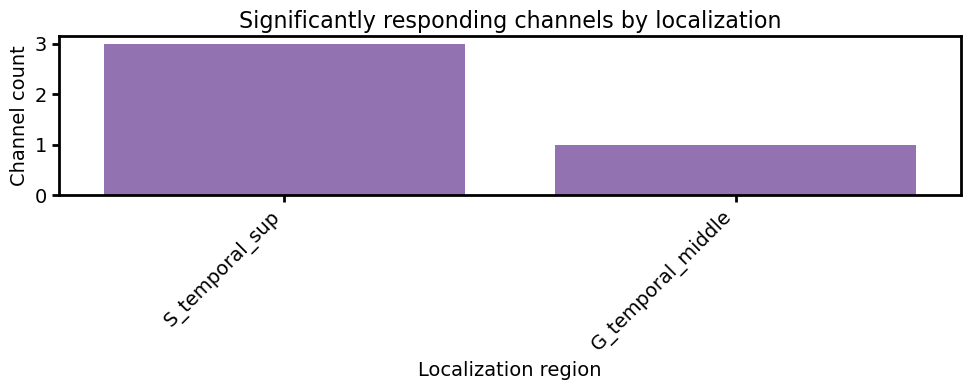

,region,count
0,S_temporal_sup,3
1,G_temporal_middle,1


In [12]:
# Distribution of significantly responding channels by localization
sig_selected = sig_df[sig_df['dataset_name'].isin(analysis_dataset_names)].copy()
print(f"Using abs(t_stat) threshold for significant channel selection.")
region_counts = sig_selected['region'].value_counts().reset_index()
region_counts.columns = ['region', 'count']

plt.figure(figsize=(10, 4))
sns.barplot(data=region_counts, x='region', y='count', color='tab:purple')
plt.xticks(rotation=45, ha='right')
plt.title('Significantly responding channels by localization')
plt.ylabel('Channel count')
plt.xlabel('Localization region')
plt.tight_layout()
plt.show()

region_counts


In [13]:
# Feature extraction for train/test splits using selected channels

def build_features_for_windows(window_df, selected_channels):
    feature_rows = []

    window_records = []
    for _, w in window_df.iterrows():
        window_records.append(('onset', int(w['sentence_idx']), float(w['onset_movie_time']), int(w['on_start']), int(w['on_end'])))
        window_records.append(('control', int(w['sentence_idx']), float(w['onset_movie_time']), int(w['ctrl_start']), int(w['ctrl_end'])))

    gamma_sum = np.zeros(len(window_records), dtype=float)
    total_sum = np.zeros(len(window_records), dtype=float)
    count = np.zeros(len(window_records), dtype=int)

    with h5py.File(H5_PATH, 'r') as h5f:
        data_group = h5f['data']
        for ds_name in selected_channels:
            xn, xg = notch_plus_gamma_full_trace(np.asarray(data_group[ds_name][:], dtype=float), fs)

            for i, (_label, _sent, _t, s0, s1) in enumerate(window_records):
                seg_n = xn[s0:s1]
                seg_g = xg[s0:s1]
                if seg_n.size == 0 or seg_g.size == 0:
                    continue

                gamma_power = float(np.mean(seg_g ** 2))
                total_power = float(np.mean(seg_n ** 2))
                gamma_sum[i] += gamma_power
                total_sum[i] += total_power
                count[i] += 1

    for i, (label, sent_idx, onset_t, _s0, _s1) in enumerate(window_records):
        n = count[i]
        feature_rows.append({
            'sentence_idx': sent_idx,
            'onset_movie_time': onset_t,
            'label': label,
            'gamma_raw': gamma_sum[i] / n if n > 0 else np.nan,
            'total_power': total_sum[i] / n if n > 0 else np.nan,
            'n_temporal_channels_used': int(n),
        })

    out = pd.DataFrame(feature_rows)
    out['y'] = (out['label'] == 'onset').astype(int)
    return out

train_features = build_features_for_windows(train_windows, analysis_dataset_names)
test_features = build_features_for_windows(test_windows, analysis_dataset_names)
train_features['split'] = 'train'
test_features['split'] = 'test'
features = pd.concat([train_features, test_features], ignore_index=True)

assert np.isfinite(features[['gamma_raw', 'total_power']]).all().all(), 'NaN/inf in features'
assert train_features['label'].value_counts().nunique() == 1, 'Train classes are not balanced'
assert test_features['label'].value_counts().nunique() == 1, 'Test classes are not balanced'

print('train label counts:', train_features['label'].value_counts().to_dict())
print('test label counts:', test_features['label'].value_counts().to_dict())
print(features.head())


train label counts: {'onset': 534, 'control': 534}
test label counts: {'onset': 134, 'control': 134}
   sentence_idx  onset_movie_time    label  gamma_raw   total_power  \
0           540       2502.089457    onset  19.862756  24498.097507   
1           540       2502.089457  control  16.249538  25833.962304   
2           428       1851.240000    onset  18.099899  19958.674600   
3           428       1851.240000  control   8.934485  16310.413723   
4           245       1125.523172    onset  25.634939   8024.306306   

   n_temporal_channels_used  y  split  
0                         4  1  train  
1                         4  0  train  
2                         4  1  train  
3                         4  0  train  
4                         4  1  train  


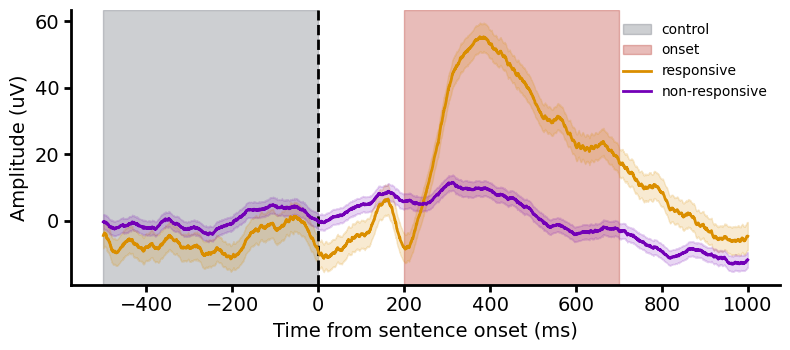

responsive: electrode_155 (n=668 trials)
non-responsive: electrode_139 (n=3072 trials)


In [27]:
# Evoked responses (paper-style): responsive vs non-responsive on one axis
if len(analysis_dataset_names) == 0:
    raise ValueError('No responsive channels available for evoked comparison.')

responsive_ds = analysis_dataset_names[0]
nonresponsive_candidates = [d for d in temporal_dataset_names if d not in analysis_dataset_names]
if len(nonresponsive_candidates) == 0:
    raise ValueError('No non-responsive temporal electrodes available for comparison.')
nonresponsive_ds = nonresponsive_candidates[-1]

pre_sec = 0.5
post_sec = 1.0
pre_n = int(round(pre_sec * fs))
post_n = int(round(post_sec * fs))
trace_len = pre_n + post_n
time_axis_ms = np.linspace(-pre_sec * 1000, post_sec * 1000, trace_len, endpoint=False)

def collect_onset_aligned_trials(x_full):
    trials = []
    for _, w in windows.iterrows():
        onset_center = int(w['ctrl_end'])
        s0 = onset_center - pre_n
        s1 = onset_center + post_n
        if s0 < 0 or s1 > x_full.size:
            continue
        seg = x_full[s0:s1]
        if seg.size == trace_len:
            trials.append(seg)
    return np.vstack(trials) if len(trials) else np.empty((0, trace_len))

def mean_sem(x):
    if x.shape[0] == 0:
        return np.zeros(x.shape[1]), np.zeros(x.shape[1])
    m = x.mean(axis=0)
    sem = x.std(axis=0, ddof=1) / np.sqrt(max(1, x.shape[0]))
    return m, sem

with h5py.File(H5_PATH, 'r') as h5f:
    g = h5f['data']
    responsive_n = notch_only_full_trace(np.asarray(g[responsive_ds][:], dtype=float), fs)
    nonresponsive_n = notch_only_full_trace(np.asarray(g[nonresponsive_ds][:], dtype=float), fs)

responsive_trials = collect_onset_aligned_trials(responsive_n)
nonresponsive_trials = collect_onset_aligned_trials(nonresponsive_n)

resp_m, resp_sem = mean_sem(responsive_trials)
nonresp_m, nonresp_sem = mean_sem(nonresponsive_trials)

fig, ax = plt.subplots(figsize=(8.0, 3.6))
# '#da8e00','#7300b7'
# sparse region cues
ax.axvspan(-500, 0, color='#5b616b', alpha=0.3, zorder=0, label='control')
ax.axvspan(200, 700, color='#b42318', alpha=0.3, zorder=0, label='onset')
ax.axvline(0, color='black', linewidth=2.0, linestyle='--', alpha=1)

# traces
ax.plot(time_axis_ms, resp_m, color='#da8e00', linewidth=2.0, label='responsive')
ax.fill_between(time_axis_ms, resp_m - resp_sem, resp_m + resp_sem, color='#da8e00', alpha=0.18)
ax.plot(time_axis_ms, nonresp_m, color='#7300b7', linewidth=2.0, label='non-responsive')
ax.fill_between(time_axis_ms, nonresp_m - nonresp_sem, nonresp_m + nonresp_sem, color='#7300b7', alpha=0.16)

# text-only labels (no legend box)
ymin, ymax = ax.get_ylim()
text_y = ymax - 0.07 * (ymax - ymin)
# ax.text(-465, text_y, 'control', fontsize=10, color='#4b5563')
# ax.text(230, text_y, 'onset', fontsize=10, color='#7a3e22')
# ax.text(740, text_y, 'responsive', fontsize=10, color='#b42318')
# ax.text(740, text_y - 0.11 * (ymax - ymin), 'non-responsive', fontsize=10, color='#4b5563')

# Remove ONLY unnecessary spines, do not touch facecolor (leave white by default)
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

ax.set_xlabel('Time from sentence onset (ms)')
ax.set_ylabel('Amplitude (uV)')
# ax.set_title('Evoked response comparison')
plt.legend()
ax.grid(False)

plt.tight_layout()
plt.show()

print(f'responsive: {responsive_ds} (n={responsive_trials.shape[0]} trials)')
print(f'non-responsive: {nonresponsive_ds} (n={nonresponsive_trials.shape[-1]} trials)')


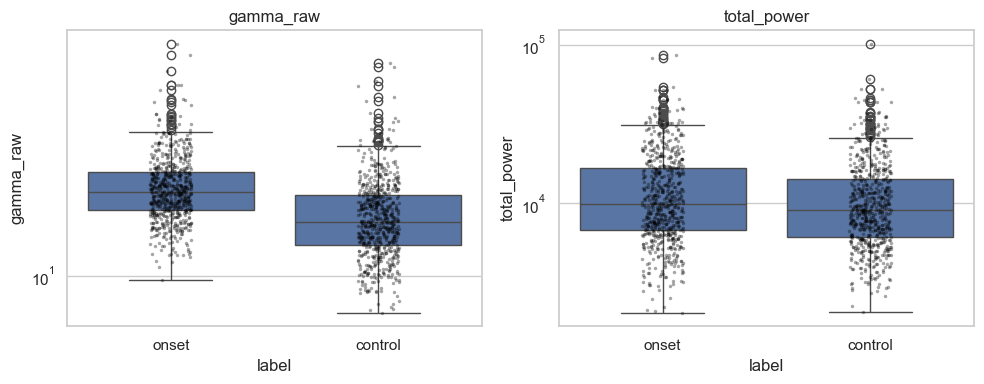

In [14]:
# Feature distributions
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col in zip(axes, ['gamma_raw', 'total_power']):
    sns.boxplot(data=features, x='label', y=col, ax=ax)
    sns.stripplot(data=features, x='label', y=col, color='black', alpha=0.35, size=2.5, ax=ax)
    ax.set_title(col)
    ax.set_yscale('log')
plt.tight_layout()
plt.show()


In [15]:
# Linear classifier baselines (fit on train, evaluate on held-out test)
X_cols = ['gamma_raw', 'total_power']
X_train = train_features[X_cols].to_numpy()
y_train = train_features['y'].to_numpy()
X_test = test_features[X_cols].to_numpy()
y_test = test_features['y'].to_numpy()


def fit_eval_logreg(Xtr, Xte, ytr, yte):
    pipe = Pipeline([
        ('scaler', RobustScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=RNG)),
    ])
    pipe.fit(Xtr, ytr)
    proba = pipe.predict_proba(Xte)[:, 1]
    pred = (proba >= 0.5).astype(int)
    return pipe, {
        'auc': roc_auc_score(yte, proba),
        'acc': accuracy_score(yte, pred),
        'proba': proba,
        'pred': pred,
    }

results = []
for i, col in enumerate(X_cols):
    _, metrics = fit_eval_logreg(X_train[:, [i]], X_test[:, [i]], y_train, y_test)
    results.append({'model': f'logreg_{col}', 'auc': metrics['auc'], 'accuracy': metrics['acc']})

multi_model, multi_metrics = fit_eval_logreg(X_train, X_test, y_train, y_test)
results.append({'model': 'logreg_all_features', 'auc': multi_metrics['auc'], 'accuracy': multi_metrics['acc']})

results_df = pd.DataFrame(results).sort_values('auc', ascending=False)
results_df


,model,auc,accuracy
0,logreg_gamma_raw,0.743818,0.656716
2,logreg_all_features,0.740254,0.660448
1,logreg_total_power,0.541156,0.544776


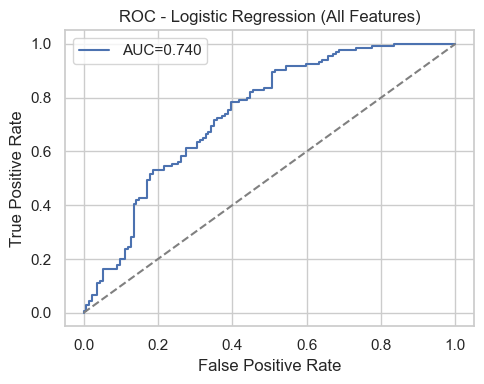

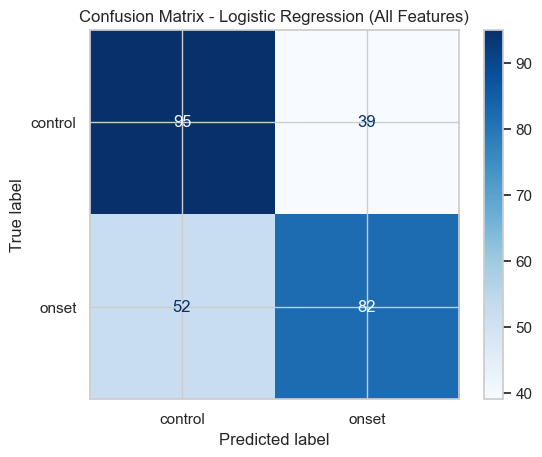

In [ ]:
# ROC + confusion matrix for multifeature model
fpr, tpr, _ = roc_curve(y_test, multi_metrics['proba'])
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test, multi_metrics['proba']):.3f}")
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC - Logistic Regression (All Features)')
plt.legend()
plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, multi_metrics['pred'])
ConfusionMatrixDisplay(cm, display_labels=['control', 'onset']).plot(cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression (All Features)')
plt.show()

In [17]:
# Export features and print concise interpretation
out_dir = ROOT / 'notebooks' / 'outputs'
out_dir.mkdir(parents=True, exist_ok=True)
out_csv = out_dir / 'trial0_stg_gamma_features_500ms.csv'
features.to_csv(out_csv, index=False)

print(f'Exported feature table: {out_csv}')
print('Model performance summary:')
print(results_df.to_string(index=False))

coefs = multi_model.named_steps['clf'].coef_[0]
coef_df = pd.DataFrame({'feature': X_cols, 'coef': coefs}).sort_values('coef', ascending=False)
print('\nMultifeature logistic regression coefficients (positive => more onset-like):')
print(coef_df.to_string(index=False))


Exported feature table: /Users/wojemann/local_data/gamma-recon/brain_tree/notebooks/outputs/trial0_stg_gamma_features_500ms.csv
Model performance summary:
              model      auc  accuracy
   logreg_gamma_raw 0.743818  0.656716
logreg_all_features 0.740254  0.660448
 logreg_total_power 0.541156  0.544776

Multifeature logistic regression coefficients (positive => more onset-like):
    feature     coef
  gamma_raw 0.902990
total_power 0.194728
